# This notebook documents the UQ of Marini, 2021 Pu-9 nu-bar experimental data. These data were released to NEA WPEC SG-52 (LA-UR-26-23411)

## Here the necessary classes and functions are loaded

In [3]:
import os
import matplotlib.pyplot as plt
%matplotlib inline 
from numpy import array, shape, ones, zeros, loadtxt, arange, sqrt
from importlib import reload

In [4]:
homedir = os.getcwd() +'/'

In [5]:
cd ../../../src

/Users/dneudecker/Documents/Codes/ARIADNE-github/src


In [6]:
import Class_nubar as Cnubar
reload(Cnubar)

<module 'Class_nubar' from '/Users/dneudecker/Documents/Codes/ARIADNE-github/src/Class_nubar.py'>

## Information from Paola Marini and Julien Taieb

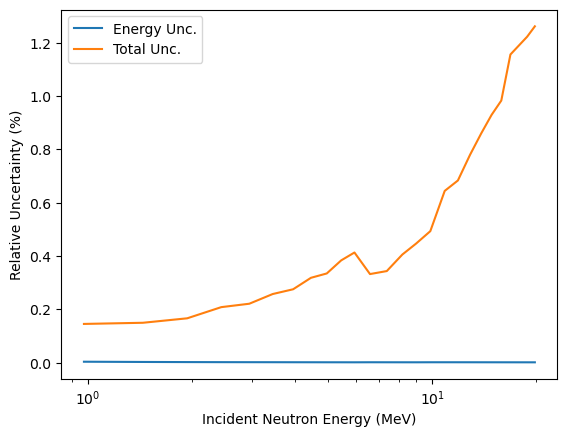

In [8]:
# Originally provided in private communication, now in EXFOR.
datafile = homedir+'PuWNR_nubar_papierNubar-Remove18MeV.dat'
alldata  = loadtxt(datafile,skiprows=7)
Einc = alldata[:25,2] 
Eunc = alldata[:25,3]*100.0/Einc
Data = alldata[:25,4]
Totunc = alldata[:25,5]*100.0/Data
#Statunc = sqrt(Totunc*Totunc-Systunc*Systunc)
#Statunc = Statunc*100.0/Data
Data = Data/3.759 # divided through old monitor (Cf-252(0,sf) prompt nu)

impurityunc = ones(shape(Einc)[0],dtype = float)*0.1
# The impurity level of Cf-252 was such that no impurity unc. apply.
# The purity level Pu-239 is 99.9% comparable to Conde who cites 
# 0.2% unc. Julien states 0.01% impact. I take the middle ground
# of 0.1%.

plt.xlabel('Einc (MeV)')
plt.ylabel('Unc. (%)')
#plt.plot(Einc,Statunc)
plt.semilogx(Einc,Eunc)
plt.semilogx(Einc,Totunc)
plt.xlabel('Incident Neutron Energy (MeV)')
plt.ylabel('Relative Uncertainty (%)')
plt.legend(["Energy Unc.","Total Unc."])

## Uncertainties specifically estimated for this experiments are given.
#### They overwrite template uncertainties.

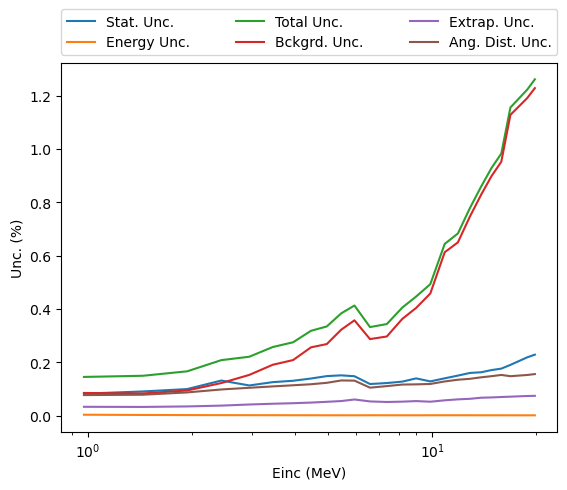

In [10]:
# Comment: Einc is the same in both files.
# Comment: Eunc is the same in both files.
# Comment: Total uncertainties are the same in both files.

datafile = homedir+'PuWNR_CorrectionsNubarAvecIncert_papierNubar-Remove18MeV.dat'
alldata  = loadtxt(datafile,skiprows=7)
backgroundunc = alldata[:25,12] 
angdistunc = alldata[:25,11]
extraunc = alldata[:25,10]
Statunc = sqrt(Totunc*Totunc-(backgroundunc*backgroundunc+angdistunc*angdistunc+\
          extraunc*extraunc))

multiplescatteringunc = ones(shape(Einc)[0],dtype = float)*0.2

plt.xlabel('Einc (MeV)')
plt.ylabel('Unc. (%)')
plt.plot(Einc,Statunc)
plt.semilogx(Einc,Eunc)
plt.semilogx(Einc,Totunc)
plt.semilogx(Einc,backgroundunc)
plt.semilogx(Einc,extraunc)
plt.semilogx(Einc,angdistunc)
plt.legend(['Stat. Unc.',"Energy Unc.","Total Unc.",\
           "Bckgrd. Unc.","Extrap. Unc.","Ang. Dist. Unc."],\
          bbox_to_anchor=(0., 1.02, 1., .102), loc=3,ncol=3, mode="expand", borderaxespad=0.)

## Uncertainties filled in from template paper. 


In [12]:
delayedgunc = ones(shape(Einc),dtype = float)*0.12
falsefissionunc = ones(shape(Einc),dtype = float)*0.22
# They use a random trigger to describe random coincidences and claim close to
# zero uncertainty.
        


## Listing of corrections undertaken: only for documentation purpose.
- Background: y (wrap-around). Uncertainties given.
- Delayed gammas: y via PSD. Ask for uncertainties. 
- False-fission event: y. random trigger
- Impurity: y. impurity level very similar to Conde who cites 0.2% unc. while they claim impact of 0.01%. Take middle ground as unc. 
- Deadtime: y, very small uncertainties.
- PFNS: N/A as unc. encompass that.
- Angular distribution/ anisotropy of FF distribution: y. Uncertainties given.
- Sample thickness: N/A as same sample thickness for Pu-9 and U-5.
- Displacement of sample: N/A with this technique. Neutron leakage enters through multiple scattering.
- Energy spread: y. Uncertainties given.
- Beam stability: y. Monitored.
- Forward boost: y
- Neutron-detection efficiency: y
- Multiple scattering of incoming neutrons: ask. 
## comments: 
- Uncertainties called out by Paola: multiple scattering, limited Eout range (extrapolation), limited coverage of angular distributions.
- Explicitly given uncertainties: energy uncertainties, extrapolation, angular distribution, wrap-around background uncertainties.
- Uncertainties that are missing and I need to ask about: random coincidences. Gamma background uncertainties. Impurity uncertainties. Multiple-scattering uncertainties (don't ask, they will say it is zero).
- The impurity level of Cf-252 was such that no impurity unc. apply. The purity level Pu-239 is 99.9% (rest Pu-240) comparable to Conde who cites  0.2% unc. Julien states 0.01% impact. I take the middle ground of 0.1%.
- They correct random coincidences by randomly triggering a gate and measuring it and claim no uncertainty. Zero unc. in this correction is not supported by literature. I take the template value.
- They apply the same gamma cuts to Pu-239 and Cf-252, which also cut out some neutrons because they really want to get out gammas. I think that could bias the PFNS and there is also a difference between gammas from Pu-239 than from Cf-252. So, there is a remaining unc. I take the template value. 
- Data are cut above 20 MeV after private communication with Paoal who wrote:We corrected for the forward boost of FF when accounting for the angular distribution of neutrons. However I have to mention that, as we do not measure Eout>14MeV, we trust our nubar values up to 20MeV Ein. Above this energy the pre-equilibrium emission w/ n above 14MeV becomes significant, so you should consider the nubar values only as a lower limit.
- I take multiple scattering unc. at unc. of 0.2% as Paola said the unc. are similar in size.

## ARIADNE call and UQ estimate.
#### The correlation values are pre-filled using the template values and can be replaced for each specific data set.

Testing covariance matrix of type Diagonal:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Positive_fully:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

Testing covariance matrix of type Gaussian:
Ok: Matrix is symmetric.
Ok: Matrix is positive semi-definite.

/Users/dneudecker/Documents/Codes/ARIADNE-github/
REFERENCE_LIBRARY_FILE: /Users/dneudecker/Documents/Codes/ARIADNE-gi

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


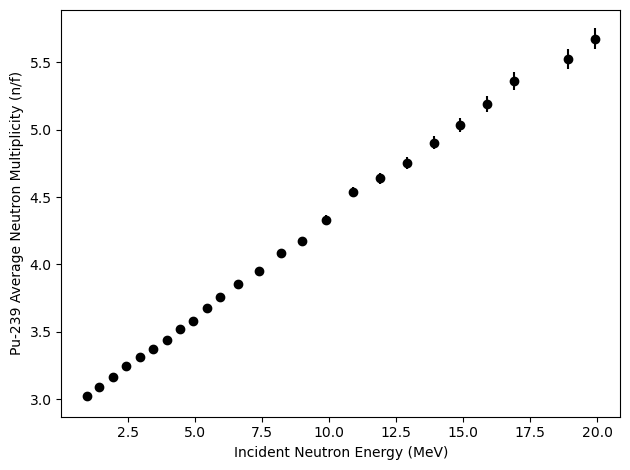

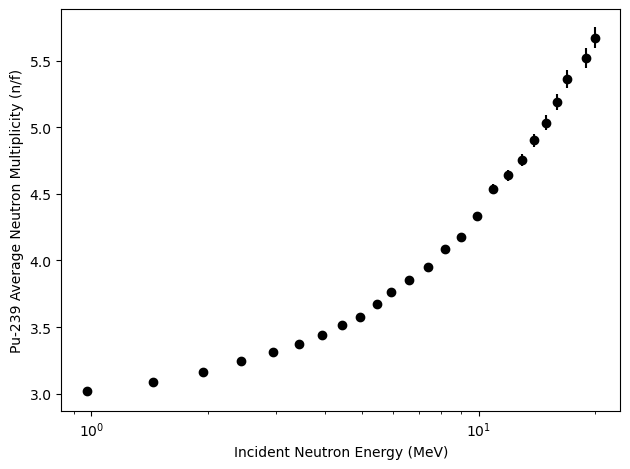

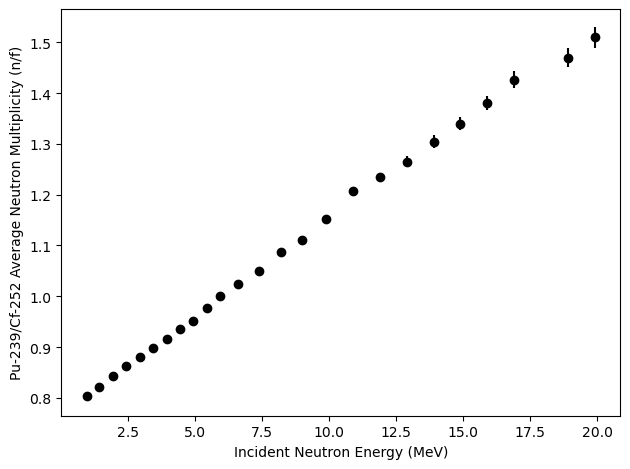

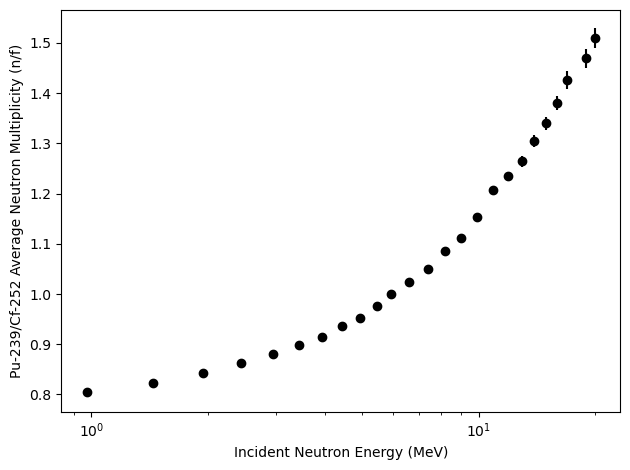

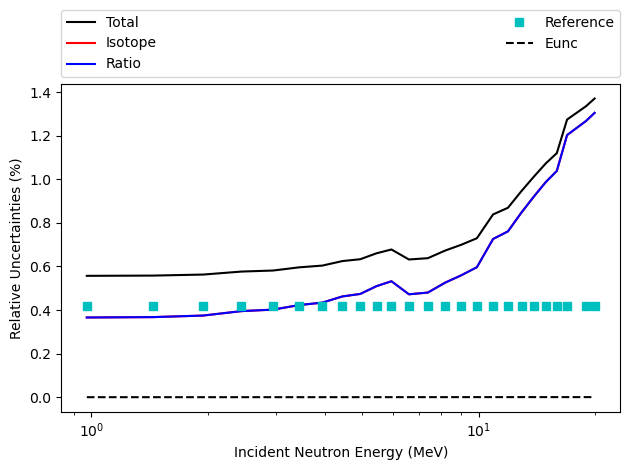

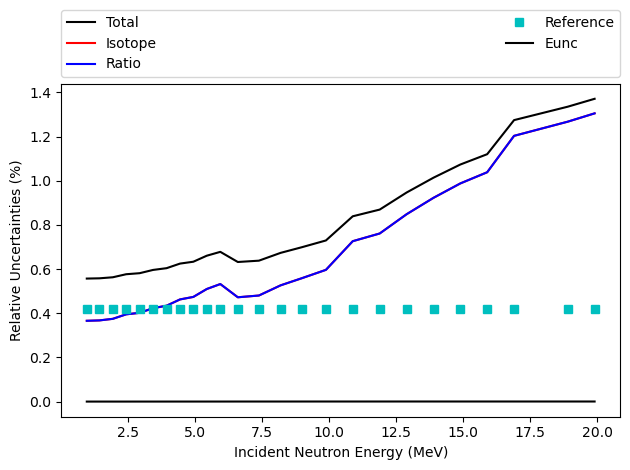

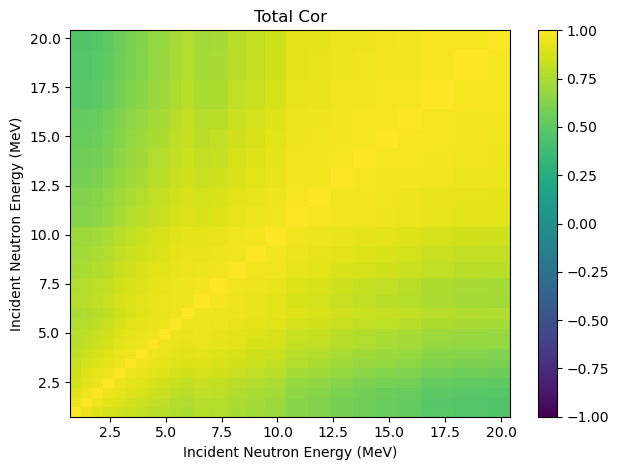

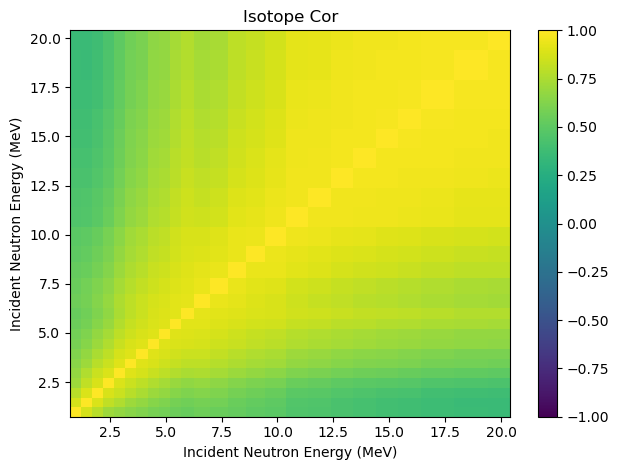

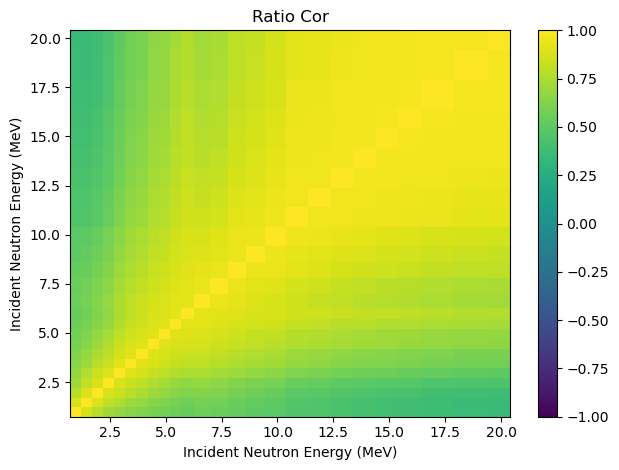

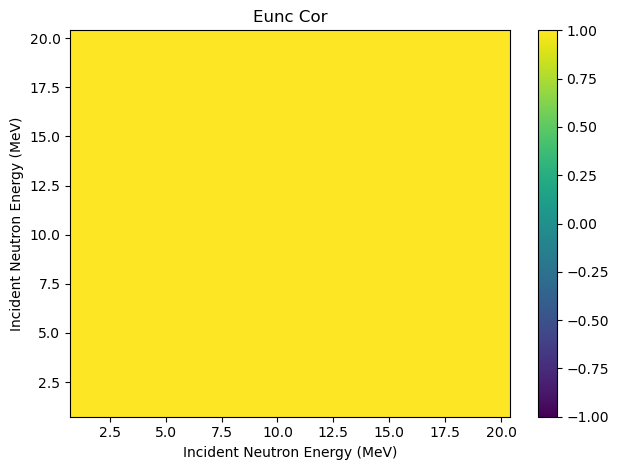

In [15]:
Documentation = """EXFOR No. = 14799002. Journal article = Marini,\
    et al., to be submitted to PRL. Uncertainties called out by Paola: multiple \
    scattering, limited Eout range (extrapolation), limited coverage of angular \
    distributions. Explicitly given uncertainties: energy uncertainties, extrapolation, \
    angular distribution, wrap-around background uncertainties. \
    Uncertainties that are missing and I asked about: random coincidences. \
    Gamma background uncertainties. Impurity uncertainties. Multiple-scattering \
    uncertainties. The impurity level of Cf-252 was such that no impurity unc. \
    apply. The purity level Pu-239 is 99.9% (rest Pu-240) comparable to Conde who \
    cites  0.2% unc. Julien states 0.01% impact. I take the middle ground of 0.1%. \
    They correct random coincidences by randomly triggering a gate and measuring it \
    and claim no uncertainty. Zero unc. in this correction is not supported by literature. \
    I take the template value. They apply the same gamma cuts to Pu-239 and Cf-252, \
    which also cut out some neutrons because they really want to get out gammas. \
    I think that could bias the PFNS and there is also a difference between gammas \
    from Pu-239 than from Cf-252. So, there is a remaining unc. I take the template \
    value. Data are cut above 20 MeV after private communication with Paoal who wrote: \
    We corrected for the forward boost of FF when accounting for the angular \
    distribution of neutrons. However I have to mention that, as we do not \
    measure Eout>14MeV, we trust our nubar values up to 20MeV Ein. Above \
    this energy the pre-equilibrium emission w/ n above 14MeV becomes \
    significant, so you should consider the nubar values only as a lower limit.\
    I take multiple scattering unc. at unc. of 0.2% as Paola said the unc. are \
    similar in size. As should be obvious from the discussion above private \
    communication with authors took place."""         

general_info = {'name': 'nubar_Marini2021', 'isotope': 'Pu-239', 'quantity': 'nubar-prompt', 'reaction': 'n,f', \
                'output_file' : homedir+'nubar_Marini2021.xml', \
                'output_folder' : homedir,\
                'documentation' : Documentation}

einc_unc = {'en_err' : {'enerr_unc': Eunc,'enerr_unc_unit': '%',\
                      'enerr_unc_type':'Positive_fully','enerr_unc_type_arg':{}},\
            'identifier_iso_deriv1' : 'ENDF/B-VIII.0'}

reference = {'isotope': 'Cf-252','quantity': 'nubar-prompt', 'reaction': '0,f',\
             'identifier':'ENDF/B-VIII.0'}


unc_iso = {'einc_unc': einc_unc,\
           'values':array([Statunc,delayedgunc,falsefissionunc,backgroundunc,\
                          extraunc,angdistunc,impurityunc,multiplescatteringunc]).transpose(),\
           'units':['%','%','%','%','%','%','%','%','%'],\
           'type':['Diagonal','Positive_fully','Gaussian','Positive_fully',\
                  'Gaussian','Gaussian','Positive_fully','Gaussian'],\
           'type_arg':{'einc':array(Einc),\
                       'damp_term':[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],}}

features = {'Author':'Marini','Year':'2021',\
            'MonitorReaction':'(98-CF-252(0,F),PR,NU)','EXFORnumber':'14799002',\
            'AcceptedVsRejected':'accepted',\
            'MissingCorrections':'impurities; multiple scattering; angular distribution; forward-boost; random coincidences',\
            'BackgroundCorrected':'y','MultipleScatteringCorrected':'n',\
            'FoilThicknessCorrected':'N/A',\
            'AngularDistributionFissionFragmentsCorrected':'y',\
            'ForwardBoostCorrected':'n',\
            'DeadtimeCorrected':'y',\
            'ImpuritiesCorrected':'unknown',\
            'GeometryCorrected':'y','NeutronFluxVariationCorrected':'y',\
            'DelayedGammasCorrected':'y','PFNSCorrected':'y',\
            'NeutronDetectionEfficiencyCorrected':'y',\
            'DisplacementSampleCorrected':'N/A',\
            'FalseFissionCorrected':'unknown',\
}

data = {'einc': array(Einc), 'einc_unit': 'MeV', 'values':array(Data), 'values_unit': "n/f" }

Marini2021 = Cnubar.nubar_cleanratioabsolute(general_info,data,unc_iso,reference,features)